# Diyabet Tahmini

Bu projede, bireylerin diyabet hastası olup olmadığını tahmin edebilen bir makine öğrenmesi modeli geliştirilmesi amaçlanmaktadır. Bu amaç doğrultusunda, kişilere ait sağlık ölçümleri ile yaşam tarzına ilişkin veriler birlikte değerlendirilerek modeller oluşturulacaktır. Geliştirilen modellerin başarımı yalnızca genel doğruluk oranlarıyla değil, aynı zamanda confusion matrix analizi kullanılarak da incelenecektir. Bu sayede, modelin gerçekten diyabet olan bireyleri ne ölçüde doğru tahmin edebildiği ve diyabet olmayan bireyleri ne kadar başarılı bir şekilde ayırt edebildiği değerlendirilecektir. Elde edilen sonuçlar doğrultusunda, farklı modeller karşılaştırılarak bu proje için en uygun ve en güvenilir model belirlenmiş olacaktır.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diabet-dataset/diabetes_dataset.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/diabet-dataset/diabetes_dataset.csv")
df.head()



,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
df.shape

(100000, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [6]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [7]:
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [8]:
df.corr(numeric_only=True)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
age,1.000000,0.000994,0.003352,-0.003326,-0.002802,-0.004704,-0.002877,0.177706,0.146797,0.092643,...,0.309717,-0.016358,0.281275,0.039449,0.231533,0.132479,0.045412,0.159447,0.495924,0.137713
alcohol_consumption_per_week,0.000994,1.000000,-0.002185,-0.000265,0.001556,0.001004,0.002531,-0.007079,-0.004311,-0.001867,...,0.002618,0.000039,0.001258,0.126674,0.006401,0.004875,0.001199,0.006174,0.010650,0.000760
physical_activity_minutes_per_week,0.003352,-0.002185,1.000000,-0.002470,-0.004735,0.000996,-0.007021,-0.001176,0.000466,-0.071907,...,-0.009555,0.018044,-0.014119,-0.026527,-0.161946,-0.093936,-0.034063,-0.112897,-0.348121,-0.100774
diet_score,-0.003326,-0.000265,-0.002470,1.000000,0.001255,0.002113,0.000336,0.001806,0.003828,-0.201303,...,-0.038603,0.042245,-0.046451,-0.080243,-0.072518,-0.044419,-0.080716,-0.054068,-0.144891,-0.044298
sleep_hours_per_day,-0.002802,0.001556,-0.004735,0.001255,1.000000,0.004732,0.003642,0.004753,-0.000437,0.000400,...,0.001996,-0.001898,0.002269,-0.003772,0.000834,0.000497,0.000433,0.001436,0.003136,-0.000399
screen_time_hours_per_day,-0.004704,0.001004,0.000996,0.002113,0.004732,1.000000,-0.001641,-0.001567,-0.002255,-0.003019,...,0.000734,-0.000931,0.001473,-0.003494,0.034692,0.020400,0.001902,0.024197,0.071284,0.018127
family_history_diabetes,-0.002877,0.002531,-0.007021,0.000336,0.003642,-0.001641,1.000000,0.003300,0.001188,0.000309,...,-0.003697,-0.006730,-0.000641,0.002813,0.344724,0.204469,0.016186,0.242136,0.733085,0.197926
hypertension_history,0.177706,-0.007079,-0.001176,0.001806,0.004753,-0.001567,0.003300,1.000000,0.022182,0.014494,...,0.049581,-0.005910,0.044854,0.008957,0.047285,0.029652,0.008807,0.032591,0.091315,0.027524
cardiovascular_history,0.146797,-0.004311,0.000466,0.003828,-0.000437,-0.002255,0.001188,0.022182,1.000000,0.009956,...,0.043271,-0.002539,0.037657,0.009128,0.036177,0.029442,0.008105,0.033310,0.072970,0.029793
bmi,0.092643,-0.001867,-0.071907,-0.201303,0.000400,-0.003019,0.000309,0.014494,0.009956,1.000000,...,0.199849,-0.211899,0.238032,0.405668,0.150929,0.092818,0.391903,0.110321,0.313813,0.097057


In [9]:
df.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

In [10]:
x = df[[
    # Demografik
    'age',
    'gender',

    # Yaşam tarzı
    'smoking_status',
    'physical_activity_minutes_per_week',
    'diet_score',
    'sleep_hours_per_day',

    # Aile / geçmiş
    'family_history_diabetes',
    'hypertension_history',

    # Antropometrik
    'bmi',
    'waist_to_hip_ratio',

    # Klinik
    'systolic_bp',
    'cholesterol_total',
    'triglycerides',

    # Glukoz metabolizması
    'glucose_fasting',
    'glucose_postprandial',
    'insulin_level',
    'hba1c'
]]

y = df['diagnosed_diabetes']



In [11]:
x

,age,gender,smoking_status,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,family_history_diabetes,hypertension_history,bmi,waist_to_hip_ratio,systolic_bp,cholesterol_total,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c
0,58,Male,Never,215,5.7,7.9,0,0,30.5,0.89,134,239,145,136,236,6.36,8.18
1,48,Female,Former,143,6.7,6.5,0,0,23.1,0.80,129,116,30,93,150,2.00,5.63
2,60,Male,Never,57,6.4,10.0,1,0,22.2,0.81,115,213,36,118,195,5.07,7.51
3,74,Female,Never,49,3.4,6.6,0,0,26.8,0.88,120,171,140,139,253,5.28,9.03
4,46,Male,Never,109,7.2,7.4,0,0,21.2,0.78,92,210,160,137,184,12.74,7.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Former,136,8.3,6.4,0,0,29.8,0.93,126,227,116,113,109,14.58,5.55
99996,41,Female,Never,76,8.8,6.8,0,0,26.5,0.86,130,207,146,96,146,9.02,5.97
99997,57,Female,Former,121,9.9,5.0,0,0,25.6,0.83,107,189,184,93,132,2.57,5.21
99998,47,Female,Never,52,5.9,6.7,0,1,26.8,0.89,115,173,116,106,117,9.81,5.53


In [12]:
x=pd.get_dummies(x,drop_first=True)

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [14]:
from sklearn.naive_bayes import GaussianNB


g=GaussianNB()


In [15]:
model1=g.fit(x_train,y_train)

In [16]:
tahmin1=model1.predict(x_test)

In [17]:
accuracy_score(tahmin1,y_test)

0.8557

In [18]:
print(classification_report(tahmin1,y_test))

              precision    recall  f1-score   support

           0       0.85      0.80      0.83      8601
           1       0.86      0.90      0.88     11399

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



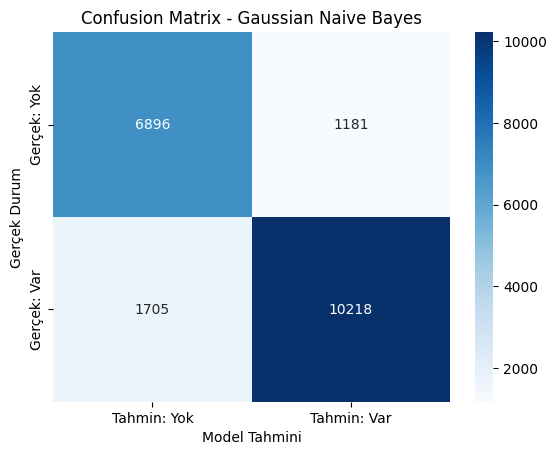

In [19]:
cm_nb = confusion_matrix(y_test, tahmin1)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin: Yok', 'Tahmin: Var'],
            yticklabels=['Gerçek: Yok', 'Gerçek: Var'])

plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Model Tahmini")
plt.ylabel("Gerçek Durum")
plt.show()


In [20]:
from sklearn.linear_model import LogisticRegression
lo=LogisticRegression()

In [21]:
model2 = lo.fit(x_train, y_train)


In [22]:
tahmin2 = model2.predict(x_test)

In [23]:
accuracy_score(y_test, tahmin2)


0.7878

In [24]:
print(classification_report(y_test, tahmin2))


              precision    recall  f1-score   support

           0       0.76      0.69      0.72      8077
           1       0.80      0.86      0.83     11923

    accuracy                           0.79     20000
   macro avg       0.78      0.77      0.78     20000
weighted avg       0.79      0.79      0.79     20000



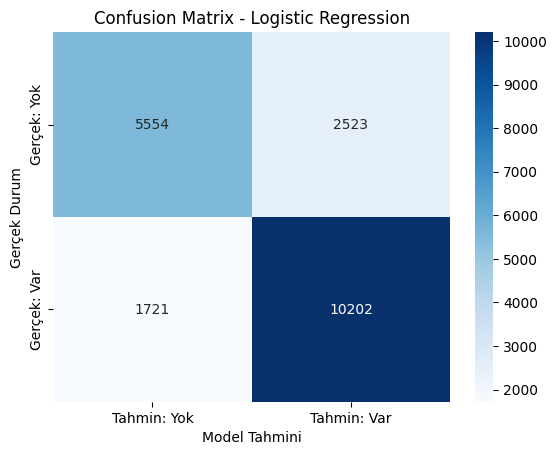

In [25]:
cm_lr = confusion_matrix(y_test, tahmin2)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin: Yok', 'Tahmin: Var'],
            yticklabels=['Gerçek: Yok', 'Gerçek: Var'])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Model Tahmini")
plt.ylabel("Gerçek Durum")
plt.show()


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()


In [27]:
model3 = rf.fit(x_train, y_train)


In [28]:
tahmin3 = model3.predict(x_test)


In [29]:
accuracy_score(y_test, tahmin3)


0.9202

In [30]:
print(classification_report(y_test, tahmin3))


              precision    recall  f1-score   support

           0       0.84      1.00      0.91      8077
           1       1.00      0.87      0.93     11923

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



In [31]:
from sklearn.metrics import confusion_matrix

cm3 = confusion_matrix(y_test, tahmin3)
print(cm3)


[[ 8077     0]
 [ 1596 10327]]


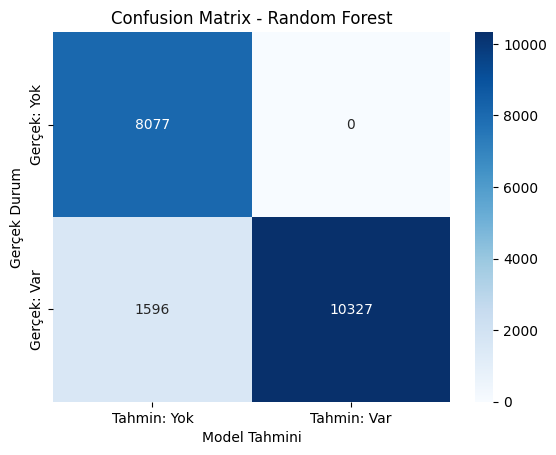

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin: Yok', 'Tahmin: Var'],
            yticklabels=['Gerçek: Yok', 'Gerçek: Var'])
plt.xlabel("Model Tahmini")
plt.ylabel("Gerçek Durum")
plt.title("Confusion Matrix - Random Forest")
plt.show()


TN (Doğru Negatif) = 8075
FP (Yanlış Pozitif) = 2
FN (Yanlış Negatif) = 1596
TP (Doğru Pozitif) = 10327

Yanlış Pozitif neredeyse yok (FP = 2)
Model “diyabet var” dediğinde neredeyse hiç yanılmıyor.

Yanlış Negatifler var (FN = 1596)
1596 diyabetli kişi, model tarafından “yok” denmiş.
Klinik risk: Bazı hastalar gözden kaçabilir ve erken teşhis, tedavi gecikebilir.

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

In [34]:
model4 = dt.fit(x_train, y_train)


In [35]:
tahmin4 = model4.predict(x_test)


In [36]:

accuracy_score(y_test, tahmin4)

0.86235

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, tahmin4))


              precision    recall  f1-score   support

           0       0.84      0.82      0.83      8077
           1       0.88      0.89      0.89     11923

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.86     20000
weighted avg       0.86      0.86      0.86     20000



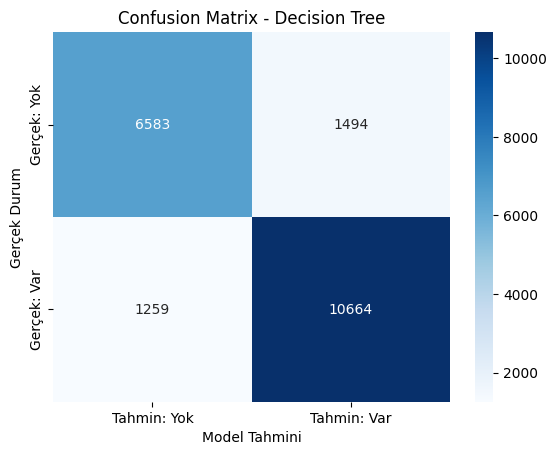

In [38]:
cm_dt = confusion_matrix(y_test, tahmin4)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin: Yok', 'Tahmin: Var'],
            yticklabels=['Gerçek: Yok', 'Gerçek: Var'])

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Model Tahmini")
plt.ylabel("Gerçek Durum")
plt.show()


## Sonuç

Bu çalışmada, bireylerin demografik, yaşam tarzı ve klinik özelliklerini kullanarak diyabet tanısını tahmin etmeyi amaçlayan bir ikili sınıflandırma problemi ele alınmıştır. Logistic Regression, Gaussian Naive Bayes, Decision Tree ve Random Forest olmak üzere dört farklı makine öğrenmesi modeli karşılaştırılmıştır. Elde edilen sonuçlara göre Random Forest sınıflandırıcısı %92.01 doğruluk oranı ile en yüksek performansı göstermiştir. Decision Tree (%86.52) ve Gaussian Naive Bayes (%85.57) modelleri orta seviyede başarı sağlarken, Logistic Regression modeli %78.78 doğruluk oranı ile en düşük performansı sergilemiştir. Confusion matrix analizleri, Random Forest modelinin özellikle diyabet tanısı koyma konusunda güvenilir olduğunu ve yanlış sınıflandırma oranının oldukça düşük olduğunu göstermektedir. Bu durum, Random Forest modelinin verideki doğrusal olmayan ilişkileri ve değişkenler arası etkileşimleri daha etkin bir şekilde öğrenebildiğini göstermektedir. Sonuç olarak, bu veri seti için en uygun modelin Random Forest olduğu ve diyabet tahmininde yüksek doğrulukla kullanılabileceği değerlendirilmiştir.